# Heart Disease ADVI Model

In [15]:
import pandas as pd
import pymc
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("./../data/heart-disease-clean.csv")

In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [18]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## ADVI with Manual Feature Selection

Columns chosen based on pearson correlation: sex, age, thalach, ca, chol 

In [19]:
selected_features = ['sex', 'age', 'thalach', 'ca', 'chol']
target = df['target']
X_selected = df[selected_features]
n_features = len(selected_features)

In [20]:
with pymc.Model() as manual_model:
    beta = pymc.Normal('beta', mu=0, sigma=1, shape=len(selected_features))
    intercept = pymc.Normal('intercept', mu=0, sigma=2)

    logit_p = intercept + pymc.math.dot(X_selected, beta)
    y = pymc.Bernoulli('y', logit_p=logit_p, observed=target)

    approx = pymc.fit(n=50000, method='advi')
    trace = approx.sample(2000)

Output()

Finished [100%]: Average Loss = 177.79


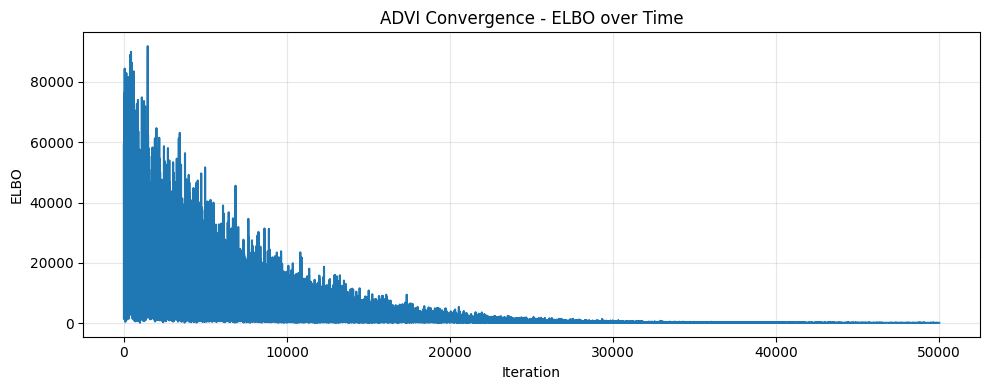

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(approx.hist)
plt.xlabel('Iteration')
plt.ylabel('ELBO')
plt.title('ADVI Convergence - ELBO over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./plots/1_advi_convergence_manual.png', dpi=150)
plt.show()

- Beta_mean = average coefficient from the Bayesian model (how much a feature affects target col)
- Beta_std = beta standard dev, uncertainty about beta mean
- ci_lower/upper = confidence interval based on the 95 percentile (lower is 2.5% upper is 97.5%)
- odds_ratio = convert log odds (beta mean) to normal odds = exp(beta_mean)
- p(direction) = probability that the effect goes in the dominant direction 
- CI_excludes_zero = true if the confidence interval doesn't include zero (credibly non zero)
- Large_Effect = true if the feature has a big influence abs(beta_mean)>threshold (i used 0.1)
- IS_Predictor = true if CI_Excludes_zero or Large_Effect

In [22]:
beta_samples = trace.posterior['beta'].values.reshape(-1, n_features)
beta_mean = np.mean(beta_samples, axis=0)
beta_std = np.std(beta_samples, axis=0)
beta_ci_lower = np.percentile(beta_samples, 2.5, axis=0)
beta_ci_upper = np.percentile(beta_samples, 97.5, axis=0)

threshold = 0.1

is_predictor_ci = (beta_ci_lower > 0) | (beta_ci_upper < 0)
is_predictor_magnitude = np.abs(beta_mean) > threshold
is_predictor = is_predictor_ci | is_predictor_magnitude


prob_positive = np.mean(beta_samples > 0, axis=0)
prob_negative = np.mean(beta_samples < 0, axis=0)
prob_direction = np.maximum(prob_positive, prob_negative) 

odds_ratio = np.exp(beta_mean)

results_manual = pd.DataFrame({
    'Feature': selected_features,
    'Beta_Mean': beta_mean,
    'Beta_Std': beta_std,
    'CI_Lower': beta_ci_lower,
    'CI_Upper': beta_ci_upper,
    'Odds_Ratio': odds_ratio,
    'P(Direction)': prob_direction,
    'CI_Excludes_Zero': is_predictor_ci,
    'Large_Effect': is_predictor_magnitude,
    'IS_PREDICTOR': is_predictor
})

In [23]:
display(results_manual)

,Feature,Beta_Mean,Beta_Std,CI_Lower,CI_Upper,Odds_Ratio,P(Direction),CI_Excludes_Zero,Large_Effect,IS_PREDICTOR
0,sex,-1.796920,0.209379,-2.199894,-1.382193,0.165809,1.0,True,True,True
1,age,-0.021915,0.003497,-0.028685,-0.015166,0.978324,1.0,True,False,True
2,thalach,0.036625,0.001276,0.034132,0.039136,1.037304,1.0,True,False,True
3,ca,-0.840558,0.164414,-1.166690,-0.521695,0.431469,1.0,True,True,True
4,chol,-0.008730,0.000741,-0.010144,-0.007258,0.991308,1.0,True,False,True


## ADVI with Automatic Feature Selection

In [24]:
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = df[feature_cols].values
y = df['target'].values

In [25]:
n_samples, n_features = X.shape

In [26]:
with pymc.Model() as automatic_model:
    tau = pymc.HalfCauchy('tau', beta=1)
    lambda_j = pymc.HalfCauchy('lambda', beta=1, shape=n_features)
    beta = pymc.Normal('beta', mu=0, sigma=tau * lambda_j, shape=n_features)
    intercept = pymc.Normal('intercept', mu=0, sigma=2)
    logit_p = intercept + pymc.math.dot(X, beta)
    y_obs = pymc.Bernoulli('y_obs', logit_p=logit_p, observed=y)
    
    approx = pymc.fit(
        n=50000,
        method='advi',
        callbacks=[pymc.callbacks.CheckParametersConvergence(tolerance=0.01)]
    )

Output()

Finished [100%]: Average Loss = 180.92


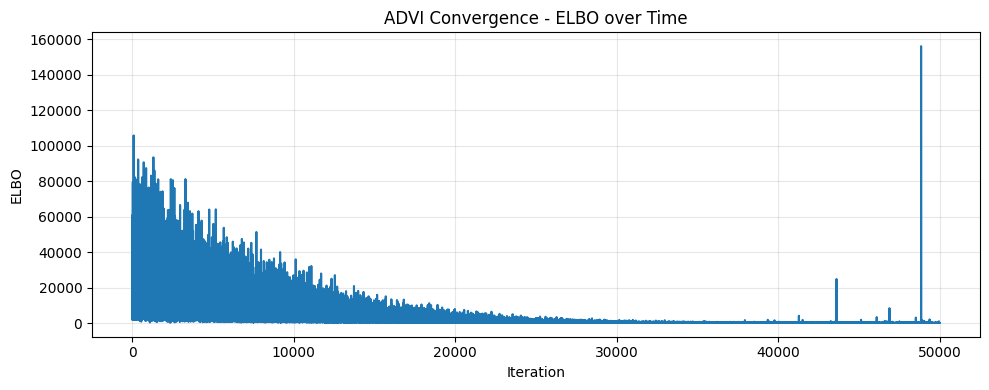

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(approx.hist)
plt.xlabel('Iteration')
plt.ylabel('ELBO')
plt.title('ADVI Convergence - ELBO over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./plots/1_advi_convergence_auto.png', dpi=150)
plt.show()

- Beta_mean = average coefficient from the Bayesian model (how much a feature affects target col)
- Beta_std = beta standard dev, uncertainty about beta mean
- ci_lower/upper = confidence interval based on the 95 percentile (lower is 2.5% upper is 97.5%)
- odds_ratio = convert log odds (beta mean) to normal odds = exp(beta_mean)
- p(direction) = probability that the effect goes in the dominant direction 
- CI_excludes_zero = true if the confidence interval doesn't include zero (credibly non zero)
- Large_Effect = true if the feature has a big influence abs(beta_mean)>threshold (i used 0.1)
- IS_Predictor = true if CI_Excludes_zero or Large_Effect

In [28]:

trace = approx.sample(2000)
beta_samples = trace.posterior['beta'].values.reshape(-1, n_features)
beta_mean = np.mean(beta_samples, axis=0)
beta_std = np.std(beta_samples, axis=0)
beta_ci_lower = np.percentile(beta_samples, 2.5, axis=0)
beta_ci_upper = np.percentile(beta_samples, 97.5, axis=0)

threshold = 0.1

is_predictor_ci = (beta_ci_lower > 0) | (beta_ci_upper < 0)
is_predictor_magnitude = np.abs(beta_mean) > threshold
is_predictor = is_predictor_ci | is_predictor_magnitude


prob_positive = np.mean(beta_samples > 0, axis=0)
prob_negative = np.mean(beta_samples < 0, axis=0)
prob_direction = np.maximum(prob_positive, prob_negative) 

odds_ratio = np.exp(beta_mean)

results_auto = pd.DataFrame({
    'Feature': feature_cols,
    'Beta_Mean': beta_mean,
    'Beta_Std': beta_std,
    'CI_Lower': beta_ci_lower,
    'CI_Upper': beta_ci_upper,
    'Odds_Ratio': odds_ratio,
    'P(Direction)': prob_direction,
    'CI_Excludes_Zero': is_predictor_ci,
    'Large_Effect': is_predictor_magnitude,
    'IS_PREDICTOR': is_predictor
})

In [29]:
display(results_auto)

,Feature,Beta_Mean,Beta_Std,CI_Lower,CI_Upper,Odds_Ratio,P(Direction),CI_Excludes_Zero,Large_Effect,IS_PREDICTOR
0,age,0.000959,0.006301,-0.011668,0.013029,1.000959,0.5755,False,False,False
1,sex,-2.197864,0.350177,-2.878130,-1.489336,0.111040,1.0000,True,True,True
2,cp,1.259387,0.208016,0.841807,1.665153,3.523263,1.0000,True,True,True
3,trestbps,-0.011247,0.002807,-0.016818,-0.005690,0.988816,1.0000,True,False,True
4,chol,-0.000909,0.001418,-0.003670,0.001853,0.999091,0.7355,False,False,False
5,fbs,0.000014,0.437852,-0.895589,0.858886,1.000014,0.5010,False,False,False
6,restecg,0.734064,0.358162,0.052805,1.423498,2.083530,0.9835,True,True,True
7,thalach,0.031750,0.002273,0.027441,0.036507,1.032259,1.0000,True,False,True
8,exang,-1.170585,0.495381,-2.146011,-0.226980,0.310186,0.9935,True,True,True
9,oldpeak,-0.861859,0.224045,-1.295901,-0.427533,0.422376,1.0000,True,True,True
